In [5]:
import pandas as pd
print (pd.__version__)

2.3.3


In [48]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv('data/olist_orders_dataset.csv')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
df.shape
df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [16]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [18]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [55]:
customers_orders=df.groupby("customer_id").size().reset_index(name="order_count")

In [30]:
customers_orders.head()

,customer_id,order_Count
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [36]:
customers_orders["order_count"].describe()

count    99441.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: order_count, dtype: float64

In [38]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [39]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [40]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [42]:
df[df.duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [43]:
df.shape

(99441, 8)

In [53]:
customers=pd.read_csv('data/olist_customers_dataset.csv')

In [54]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [57]:
customers.shape

(99441, 5)

In [61]:
customers.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [62]:
merged_df=df.merge(customers,on='customer_id',how='left')

In [63]:
merged_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [64]:
merged_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [65]:
merged_df.shape

(99441, 12)

In [68]:
customer_freq=merged_df.groupby('customer_unique_id').size().reset_index(name="order_count")

In [71]:
customer_freq.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [72]:
customer_freq.describe()

,order_count
count,96096.000000
mean,1.034809
std,0.214384
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,17.000000


In [75]:
customer_freq["order_count"].value_counts().head(15)

order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [77]:
payments=pd.read_csv('data/olist_order_payments_dataset.csv')

In [88]:
payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [79]:
order_revenue=payments.groupby('order_id').size().reset_index(name="order_count")

In [82]:
order_revenue['order_count'].value_counts().head(30)

order_count
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
11        8
12        8
10        5
13        3
15        2
14        2
19        2
22        1
21        1
26        1
29        1
Name: count, dtype: int64

In [83]:
orders_revenue=merged_df.merge(payments,on='order_id',how='left')

In [85]:
orders_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


In [86]:
orders_revenue.shape

(103887, 16)

In [90]:
customer_revenue = orders_revenue.groupby("customer_unique_id").agg(
    total_spend=("payment_value", "sum"),
    avg_order_value=("payment_value", "mean")
).reset_index()

In [91]:
customer_revenue.head()

,customer_unique_id,total_spend,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,27.19
2,0000f46a3911fa3c0805444483337064,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89,196.89


In [93]:
customer_analysis=customer_freq.merge(customer_revenue,on='customer_unique_id',how='left')

In [94]:
customer_analysis.head()

,customer_unique_id,order_count,total_spend,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89


In [97]:
customer_date=merged_df.groupby('customer_unique_id').agg( 
    last_purchase_date=('order_purchase_timestamp','max')
).reset_index()

In [98]:
customer_date.head()

,customer_unique_id,last_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [99]:
c_analysis=customer_analysis.merge(customer_date,on='customer_unique_id',how='left')

In [100]:
c_analysis.head()

,customer_unique_id,order_count,total_spend,avg_order_value,last_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,2017-11-14 19:45:42


In [101]:
c_analysis.shape

(96096, 5)

In [107]:
(c_analysis["last_purchase_date"].min(),
c_analysis["last_purchase_date"].max())

('2016-09-04 21:15:19', '2018-10-17 17:30:18')

In [115]:
analysis_date=c_analysis['last_purchase_date'].max()

In [116]:
c_analysis['last_purchase_date']=pd.to_datetime(c_analysis['last_purchase_date'])

In [117]:
c_analysis["days_since_last_purchase"] = (
    analysis_date - c_analysis["last_purchase_date"]
).dt.days

In [121]:
c_analysis['churn_status']=c_analysis['days_since_last_purchase'].apply(lambda x:'Churned' if x>180 else 'Active')

In [122]:
c_analysis['churn_status'].value_counts()

churn_status
Churned    68115
Active     27981
Name: count, dtype: int64

In [134]:
total_customers=c_analysis.shape[0]
churned_customers=(c_analysis['churn_status']=='Churned').sum()
active_customers=total_customers-churned_customers
churn_rate=churned_customers/total_customers*100

In [135]:
print(total_customers, churned_customers, active_customers, churn_rate)

96096 68115 27981 70.88224275724275


In [136]:
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 96096
Churned Customers: 68115
Churn Rate: 70.88 %


In [137]:
c_analysis['total_spend'].describe()

count    96096.000000
mean       166.592492
std        231.428332
min          0.000000
25%         63.120000
50%        108.000000
75%        183.530000
max      13664.080000
Name: total_spend, dtype: float64

In [138]:
def customer_segment(row):
    if row["churn_status"] == "Churned":
        return "At Risk"
    elif row["total_spend"] > c_analysis["total_spend"].quantile(0.75):
        return "High Value"
    elif row["order_count"] > 1:
        return "Loyal"
    else:
        return "One-time Buyer"

c_analysis["segment"] = c_analysis.apply(customer_segment, axis=1)

In [139]:
c_analysis['segment'].value_counts()

segment
At Risk           68115
One-time Buyer    20481
High Value         7165
Loyal               335
Name: count, dtype: int64

(array([0, 1, 2, 3]),
 [Text(0, 0, 'At Risk'),
  Text(1, 0, 'One-time Buyer'),
  Text(2, 0, 'High Value'),
  Text(3, 0, 'Loyal')])

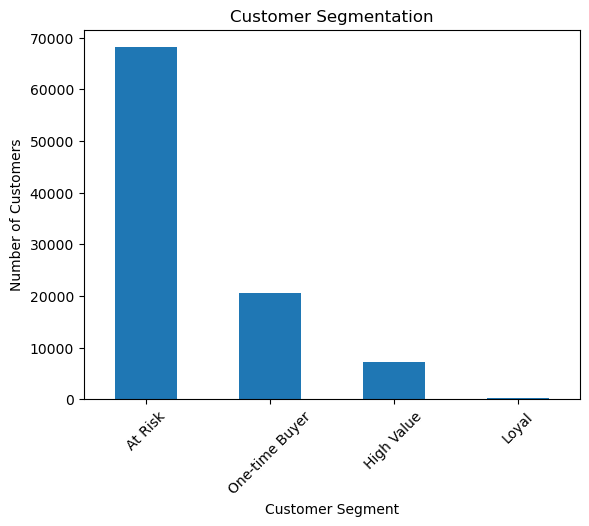

In [144]:
c_analysis["segment"].value_counts().plot(kind='bar')
plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'At Risk'),
  Text(1, 0, 'High Value'),
  Text(2, 0, 'Loyal'),
  Text(3, 0, 'One-time Buyer')])

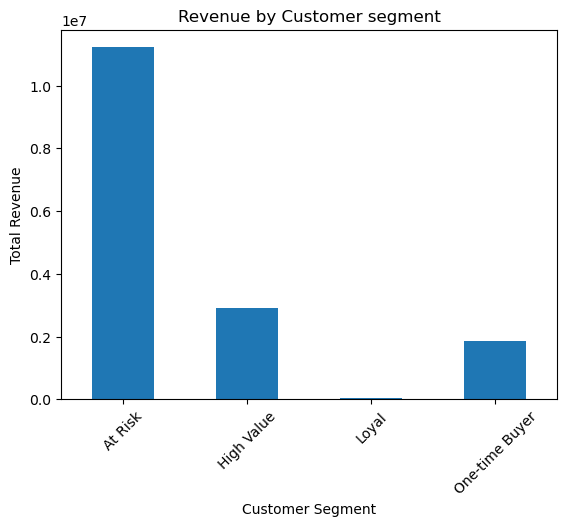

In [148]:
segment_revenue=c_analysis.groupby('segment')['total_spend'].sum()
segment_revenue.plot(kind="bar")
plt.title("Revenue by Customer segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

(array([564, 576]), [Text(564, 0, 'Jan\n2017'), Text(576, 0, 'Jan\n2018')])

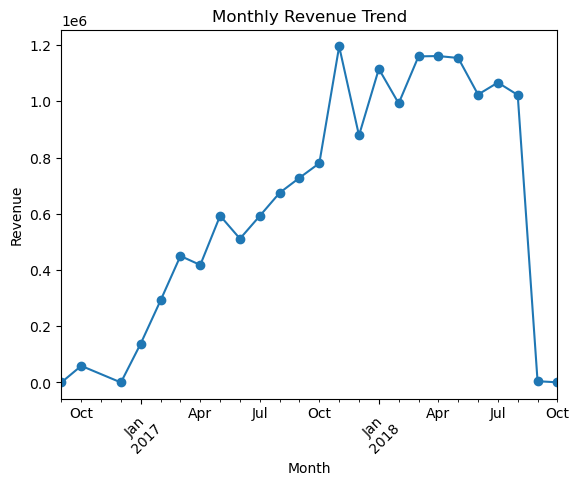

In [152]:
orders_revenue['order_purchase_timestamp']=pd.to_datetime(orders_revenue['order_purchase_timestamp'])
orders_revenue['purchase_month']=(orders_revenue['order_purchase_timestamp'].dt.to_period("M"))
monthly_revenue=orders_revenue.groupby('purchase_month')['payment_value'].sum()
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

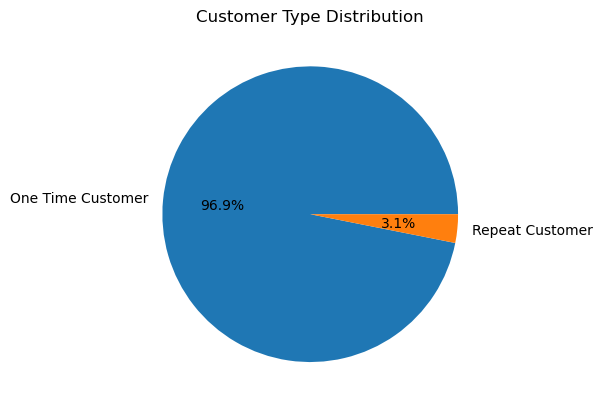

In [154]:
c_analysis['customer_type']=c_analysis['order_count'].apply(lambda x:"Repeat Customer" if x>1 else "One Time Customer")
c_analysis['customer_type'].value_counts()
c_analysis["customer_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Type Distribution")
plt.ylabel("")
plt.show()

In [155]:
correlation = c_analysis[
    ["order_count", "total_spend", "avg_order_value"]
].corr()

print(correlation)

                 order_count  total_spend  avg_order_value
order_count         1.000000     0.126032        -0.009521
total_spend         0.126032     1.000000         0.970921
avg_order_value    -0.009521     0.970921         1.000000


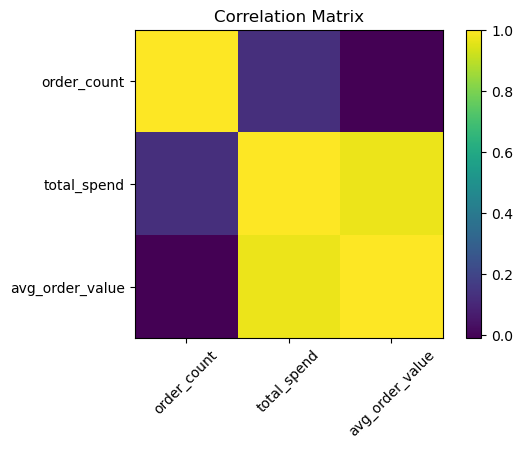

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(correlation, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")
plt.show()

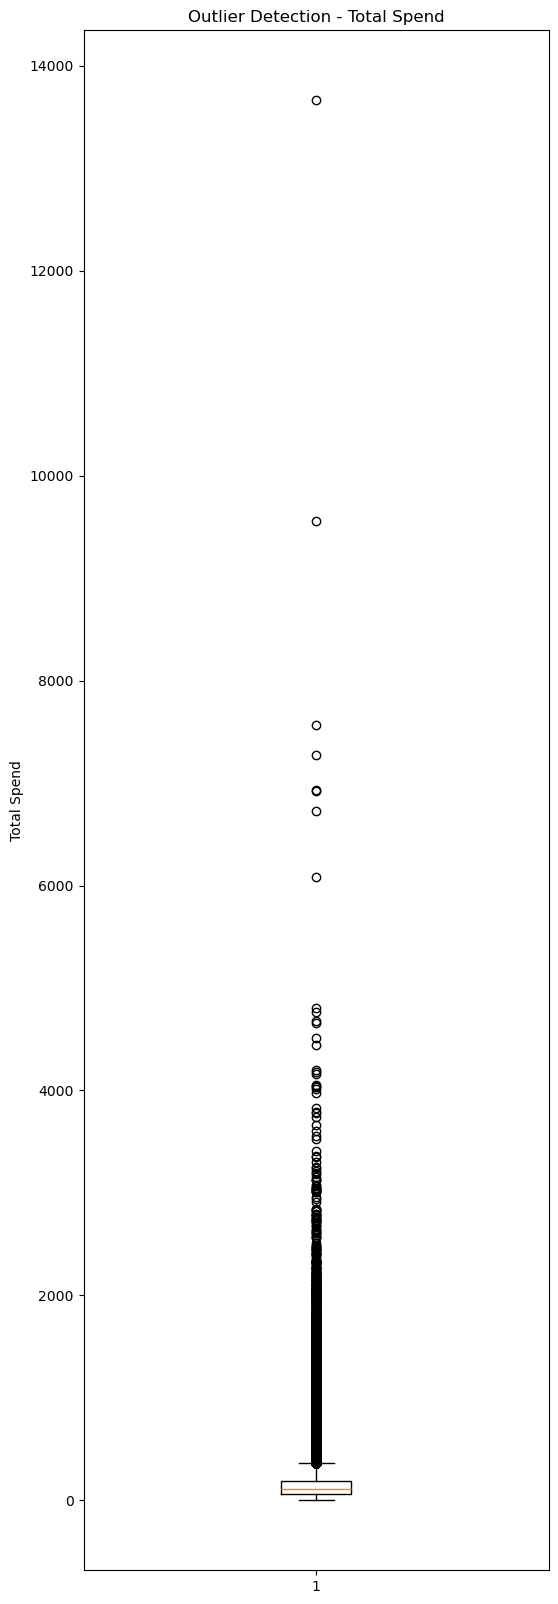

In [160]:
plt.figure(figsize=(6,20))

plt.boxplot(c_analysis["total_spend"])

plt.title("Outlier Detection - Total Spend")
plt.ylabel("Total Spend")
plt.show()

## Business Insight - Outlier Detection

- The box plot shows several high-spending outliers.
- These outliers likely represent premium or high-value customers rather than data errors.
- The company should retain these customers through loyalty programs, exclusive discounts, and personalized recommendations.
- These customers contribute significantly to overall revenue and should be a primary focus for customer retention strategies.

In [161]:
c_analysis.columns

Index(['customer_unique_id', 'order_count', 'total_spend', 'avg_order_value',
       'last_purchase_date', 'days_since_last_purchase', 'churn_status',
       'segment', 'customer_type'],
      dtype='object')

In [162]:
analysis_date = pd.to_datetime(
    c_analysis["last_purchase_date"]
).max() + pd.Timedelta(days=1)


In [163]:
analysis_date

Timestamp('2018-10-18 17:30:18')

In [164]:
c_analysis["Recency"] = (
    analysis_date - pd.to_datetime(c_analysis["last_purchase_date"])
).dt.days


In [165]:
c_analysis[["customer_unique_id", "Recency"]].head()

,customer_unique_id,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,161
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164
2,0000f46a3911fa3c0805444483337064,586
3,0000f6ccb0745a6a4b88665a16c9f078,370
4,0004aac84e0df4da2b147fca70cf8255,337


In [166]:
c_analysis["Frequency"] = c_analysis["order_count"]

c_analysis["Monetary"] = c_analysis["total_spend"]

In [167]:
c_analysis[
    ["customer_unique_id", "Recency", "Frequency", "Monetary"]
].head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [168]:
c_analysis["R_Score"] = pd.qcut(
    c_analysis["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [169]:
c_analysis["F_Score"] = pd.qcut(
    c_analysis["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [170]:
c_analysis["M_Score"] = pd.qcut(
    c_analysis["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [171]:
c_analysis[
    [
        "customer_unique_id",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score"
    ]
].head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4


In [172]:
c_analysis["RFM_Score"] = (
    c_analysis["R_Score"].astype(str) +
    c_analysis["F_Score"].astype(str) +
    c_analysis["M_Score"].astype(str)
)

In [173]:
c_analysis[
    [
        "customer_unique_id",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score"
    ]
].head()

,customer_unique_id,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4,1,1,411
2,0000f46a3911fa3c0805444483337064,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,2,1,4,214


In [174]:
def rfm_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] >= 4:
        return "Potential Loyalists"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "At Risk"
    else:
        return "Others"

c_analysis["RFM_Segment"] = c_analysis.apply(rfm_segment, axis=1)

In [175]:
c_analysis["RFM_Segment"].value_counts()

RFM_Segment
Others                 30494
Loyal Customers        19237
At Risk                15463
Champions              15453
Potential Loyalists    15449
Name: count, dtype: int64

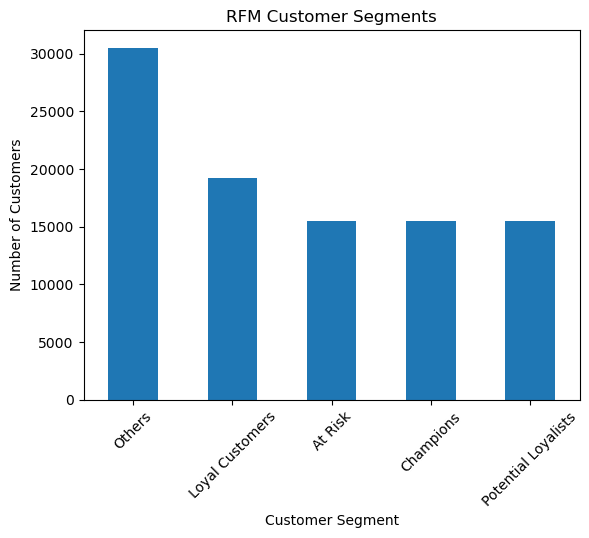

In [176]:
c_analysis["RFM_Segment"].value_counts().plot(kind="bar")

plt.title("RFM Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

## Business Insight - RFM Analysis

- Customers were segmented using Recency, Frequency, and Monetary (RFM) analysis.
- A large proportion of customers fall into the "Others" category, indicating opportunities for targeted engagement strategies.
- The "Champions" and "Loyal Customers" segments should be retained through loyalty rewards and personalized offers.
- "Potential Loyalists" can be encouraged to make repeat purchases through targeted promotions.
- "At Risk" customers should receive re-engagement campaigns to reduce customer churn.

In [177]:
c_analysis.to_csv("customer_analysis.csv", index=False)

In [179]:
import os 
os.listdir()


['.DS_Store',
 'Python',
 'Ecomm Analysis',
 'customer_analysis.csv',
 'PowerBI',
 'EcommAnalysisP.ipynb',
 'Report',
 'Data',
 'Presentation',
 'SQL']

In [180]:
reviews= pd.read_csv('data/olist_order_reviews_dataset.csv')

In [184]:
reviews.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,,,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,,,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,,,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,,,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,,,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,,,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,,,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


In [183]:
reviews=reviews.fillna("")

In [185]:
reviews.to_csv('data/olist_order_reviews_dataset.csv', index=False)

In [212]:
import pandas as pd
reviews=pd.read_csv('data/olist_order_reviews_dataset.csv')
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [213]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [217]:
reviews['review_comment_title'] = reviews['review_comment_title'].fillna("No Title")

reviews['review_comment_message'] = reviews['review_comment_message'].fillna("No Comment")

In [218]:
reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [225]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [221]:
reviews.to_csv('/Users/sreeya/Documents/Customer Churn Revenue Analysis/Data/olist_order_reviews_dataset.csv', index=False)

In [222]:
reviews['review_id'].duplicated().sum()

np.int64(814)

In [230]:
reviews=reviews.drop_duplicates(subset=['review_id'].copy())

In [224]:
reviews.shape


(98410, 7)

In [231]:
reviews['review_id'].duplicated().sum()

np.int64(0)

In [232]:
reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [234]:
reviews['review_comment_title']= reviews['review_comment_title'].fillna("No Title")

reviews['review_comment_message'] = reviews['review_comment_message'].fillna("No Comment")

In [235]:
reviews.to_csv('/Users/sreeya/Documents/Customer Churn Revenue Analysis/Data/olist_order_reviews_dataset.csv', index=False)

In [237]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
